# Exercise 1: Conceptual Questions 
## 1. Types of Bias

The scenario contains multiple forms of bias.

**Representation Bias:** The training dataset consists mainly of photos from popular influencers. Since influencers are not representative of the entire population and may contain a disproportionate number of light-skinned individuals, the model learns features that work better for those groups while performing poorly for underrepresented groups.

**Measurement Bias:** The model learns what is considered a "good" photo based on influencer images. Beauty standards reflected in the dataset may favor lighter skin tones, causing the model to incorrectly alter photos of dark-skinned users and produce unnatural results.

These biases lead to unequal performance across demographic groups and can negatively affect users who were not adequately represented in the training data.

## 2. Fairness Metrics in Practice

The fairness metric that is most aligned with the city's goal is **Equal Opportunity**.

The city wants neighborhoods with similar levels of actual fire risk to receive a similar level of resources regardless of demographic characteristics. Equal Opportunity focuses on ensuring that individuals or groups with the same true outcome have an equal chance of receiving a positive prediction.

Demographic Parity would require the same prediction rate across all neighborhoods, regardless of actual fire risk. This could result in resources being allocated inefficiently. Equal Opportunity is therefore more appropriate because it ensures fairness while still accounting for real differences in fire risk.

## 3. The Limits of Mitigation

Removing the gender column does not necessarily eliminate bias because other features may act as proxies for gender.

Examples include:

* Career breaks or employment gaps
* Occupation type
* Industry sector
* Years of experience
* College major or field of study
* Membership in professional organizations
* Part-time versus full-time employment history
* Previous job titles

These variables may be correlated with gender due to historical and societal patterns. As a result, the model can indirectly infer gender and continue producing biased outcomes even when the gender column is removed.

# Exercise 2: Auditing the "Adult" Income Dataset for Bias

#### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load dataset

In [2]:
df = pd.read_csv("adult.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(32561, 15)

Columns:
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

First 5 Rows:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female            

#### Overall percentage >50K

In [3]:
overall_high_income = (df['income'] == '>50K').mean() * 100

print("\nOverall Percentage of Income >50K:")
print(f"{overall_high_income:.2f}%")


Overall Percentage of Income >50K:
24.08%


#### Analysis by Gender

In [4]:
gender_income = (
    df.groupby('sex')['income']
    .apply(lambda x: (x == '>50K').mean() * 100)
    .reset_index(name='High Income Percentage')
)

print("\nPercentage of Income >50K by Gender:")
print(gender_income)


Percentage of Income >50K by Gender:
      sex  High Income Percentage
0  Female               10.946059
1    Male               30.573658


#### Analysis by Race

In [5]:
race_income = (
    df.groupby('race')['income']
    .apply(lambda x: (x == '>50K').mean() * 100)
    .reset_index(name='High Income Percentage')
)

print("\nPercentage of Income >50K by Race:")
print(race_income)


Percentage of Income >50K by Race:
                 race  High Income Percentage
0  Amer-Indian-Eskimo               11.575563
1  Asian-Pac-Islander               26.564004
2               Black               12.387964
3               Other                9.225092
4               White               25.585994


#### Visualization - Gender

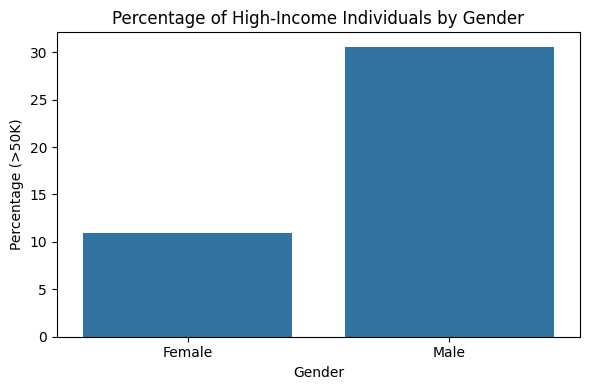

In [6]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=gender_income,
    x='sex',
    y='High Income Percentage'
)

plt.title('Percentage of High-Income Individuals by Gender')
plt.ylabel('Percentage (>50K)')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

#### Visualization - Race

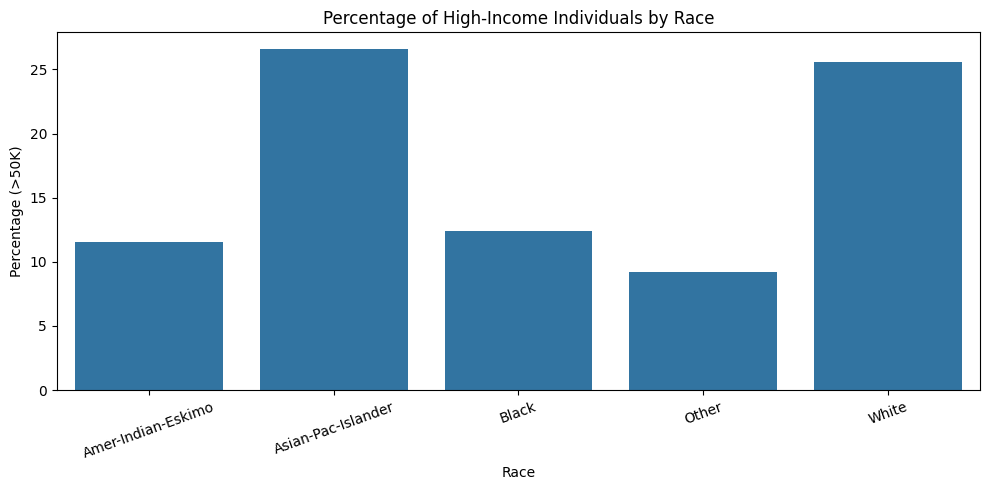

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=race_income,
    x='race',
    y='High Income Percentage'
)

plt.title('Percentage of High-Income Individuals by Race')
plt.ylabel('Percentage (>50K)')
plt.xlabel('Race')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Conclusion

The Adult Census Income dataset contains noticeable disparities across both gender and race. Men are significantly more likely to earn over $50,000 than women, and income levels also vary across racial groups. If a machine learning model were trained on this dataset without any fairness mitigation techniques, it would likely learn and reinforce these historical patterns. As a result, the model could systematically favor certain demographic groups when making predictions about income. This demonstrates the importance of fairness auditing and bias mitigation before deploying machine learning systems in real-world applications.

# Exercise 3: Challenge Problem - The Paradox of Fairness 

### Essay

Achieving perfect Demographic Parity may appear to solve a fairness problem, but it can introduce new challenges and unintended consequences. In this scenario, the bank modified its loan approval system so that both Group A and Group B receive approvals at the same rate of 50%, regardless of differences in historical repayment behavior.

One potential consequence is a negative impact on the bank's financial performance. If applicants in Group A historically have a lower default rate than applicants in Group B, reducing approvals for Group A while increasing approvals for Group B could increase the number of loan defaults. This may lead to higher financial losses and lower overall profitability. As a result, the bank may face increased risk despite achieving equal approval rates.

Another concern is the effect on Equal Opportunity. Demographic Parity focuses on equal outcomes between groups, but it does not guarantee that equally qualified applicants are treated fairly. To achieve identical approval rates, the bank may need to reject some highly qualified applicants from Group A while approving less qualified applicants from Group B. In this situation, individuals with similar creditworthiness may receive different decisions based solely on group membership, which raises concerns about fairness and merit-based evaluation.

This example demonstrates that fairness metrics can sometimes conflict with one another. Improving one measure of fairness may worsen another. Therefore, fairness cannot be reduced to a single mathematical formula.

The case also highlights the different responsibilities of data scientists and decision-makers. Data scientists should identify biases, measure trade-offs, and explain the consequences of different fairness interventions. However, determining which fairness objective should be prioritized is ultimately a business, ethical, and policy decision. Leaders, regulators, and stakeholders must decide how to balance fairness, risk, profitability, and social impact. Machine learning can provide information, but it cannot determine society's values or resolve ethical trade-offs on its own.